In [1]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt

PROJECT_ROOT_DIR = "."
CHAPTER_ID = "decision_trees"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)


def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data[:, 2:]  # petal length and width
y = iris.target

tree_clf = DecisionTreeClassifier(
    max_depth=2,
)
tree_clf.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


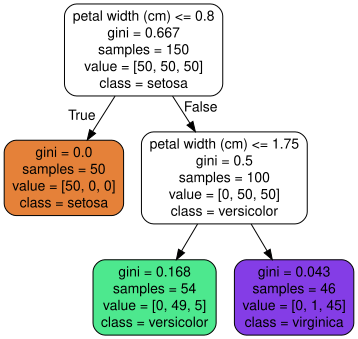

In [ ]:
from graphviz import Source
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file=os.path.join(IMAGES_PATH, "iris_tree.dot"),
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    rounded=True,
    filled=True,
)

Source.from_file(os.path.join(IMAGES_PATH, "iris_tree.dot"))

# Pruning 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree

In [5]:
data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [6]:
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

print("Training accuracy:", tree_full.score(X_train, y_train))
print("Test accuracy:", tree_full.score(X_test, y_test))

Training accuracy: 1.0
Test accuracy: 1.0


In [9]:
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.        , 0.00923521, 0.01269841, 0.01269841, 0.01847042,
       0.02705804, 0.25028684, 0.31210884])

In [10]:
trees = []

for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    tree.fit(X_train, y_train)
    trees.append(tree)

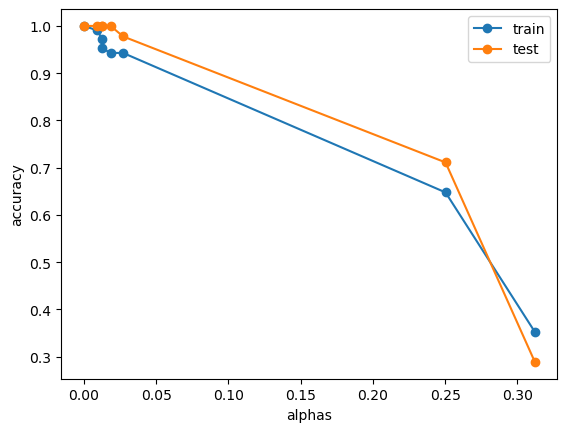

In [11]:
train_scores = [t.score(X_train, y_train) for t in trees]
test_scores = [t.score(X_test, y_test) for t in trees]

plt.plot(ccp_alphas, train_scores, marker='o', label="train")
plt.plot(ccp_alphas, test_scores, marker='o', label="test")
plt.xlabel("alphas")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [13]:
best_alpha = ccp_alphas[np.argmax(test_scores)]
best_alpha

np.float64(0.0)

In [16]:
best_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


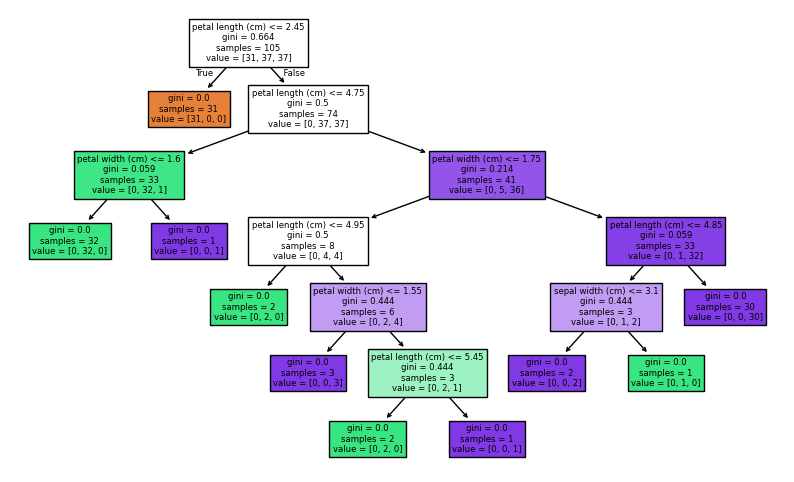

In [17]:
plt.figure(figsize=(10, 6))
plot_tree(best_tree, filled=True, feature_names=data.feature_names)
plt.show()